<!-- 
Minimal "Ideal" Structure (Reference)
1. Introduction & Objectives
2. Setup & Imports
3. Data Loading & Inspection
4. Exploratory Data Analysis
5. Preprocessing & Feature Engineering
6. Model Training
7. Model Evaluation
8. Conclusions & Next Steps
9. References (optional) 
-->

# Banknote Authentication with a Custom Perceptron

> **University:** Universidade do Vale do Rio dos Sinos (UNISINOS)<br />
> **Program:** Pós-graduação em Inteligência Artificial Aplicada<br />
> **Course:** Redes Neurais<br />
> **Author:** Augusto Stahlschmidt<br />
> **Date:** June 2, 2025  

---

## 1. Introduction & Objectives

**Problem:**  
Counterfeit banknote detection is a critical task in the financial industry. Given numerical features extracted from images of banknotes (via Wavelet Transform), the goal is to classify whether a banknote is authentic or forged.

**Task Type:**  
Binary Classification

**Business or Research Objective:**  
Build a simplified Perceptron from scratch (no high-level ML libraries for the model itself) that can reliably distinguish between genuine and forged banknotes.

**Analytical Goal:**  
Train a single-layer Perceptron using the classic weight-update rule and evaluate its accuracy on a held-out test set.

**Primary Evaluation Metric:**  
Accuracy

**Success Criteria:**  
Achieve a test accuracy significantly above the 50% random-guess baseline on the balanced dataset.

## 2. Setup & Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import train_test_split

# ── Global Configuration with reproducibility ─────────────────────────────────
SEED = 42
np.random.seed(SEED)
warnings.filterwarnings("ignore")
plt.style.use("ggplot")

print("Environment ready.")
print(f"NumPy version: {np.__version__}")

Environment ready.
NumPy version: 2.4.3


## 3. Data Loading & Initial Inspection

**Dataset Source:**  
[UCI Machine Learning Repository — Banknote Authentication](https://archive.ics.uci.edu/ml/datasets/banknote+authentication)

**Description:**  
The dataset contains 1372 samples with 4 continuous features extracted from Wavelet-Transformed images of banknotes, plus a binary class label.

**Features:**
| # | Feature | Description |
|---|---------|-------------|
| 1 | Variance | Variance of Wavelet Transformed image |
| 2 | Skewness | Skewness of Wavelet Transformed image |
| 3 | Kurtosis | Kurtosis of Wavelet Transformed image |
| 4 | Entropy  | Entropy of image |

**Unit of Analysis:**  
Individual banknote image

**Target Variable:**  
`class` — 0 = authentic, 1 = forged

**Notes:**  
- The dataset is slightly imbalanced; we apply undersampling to balance the classes before training.
- A local copy of the file is used (`data_banknote_authentication.txt`).

In [ ]:
# ── 3.1 Load raw data ─────────────────────────────────────────────────────────
DATA_PATH = "dataset/data_banknote_authentication.txt"
raw_data = np.loadtxt(DATA_PATH, delimiter=",")

X_raw = raw_data[:, :-1]  # 4 features
y_raw = raw_data[:, -1].astype(int)  # binary label

# ── 3.2 Basic inspection ──────────────────────────────────────────────────────
print(f"Dataset shape: {raw_data.shape}")
print(f"Features shape: {X_raw.shape}")
print(f"Target shape:   {y_raw.shape}")
print(f"\nClass distribution: {dict(zip(*np.unique(y_raw, return_counts=True)))}")
print(f"\nFirst 5 samples (features):")
print(X_raw[:5])
print(f"\nFirst 5 labels: {y_raw[:5]}")

Dataset shape: (1372, 5)
Features shape: (1372, 4)
Target shape:   (1372,)

Class distribution: {np.int64(0): np.int64(762), np.int64(1): np.int64(610)}

First 5 samples (features):
[[ 3.6216   8.6661  -2.8073  -0.44699]
 [ 4.5459   8.1674  -2.4586  -1.4621 ]
 [ 3.866   -2.6383   1.9242   0.10645]
 [ 3.4566   9.5228  -4.0112  -3.5944 ]
 [ 0.32924 -4.4552   4.5718  -0.9888 ]]

First 5 labels: [0 0 0 0 0]


## 4. Exploratory Data Analysis (EDA)

Goals of this section:

- Understand feature distributions per class
- Visualise class balance
- Check for obvious separability

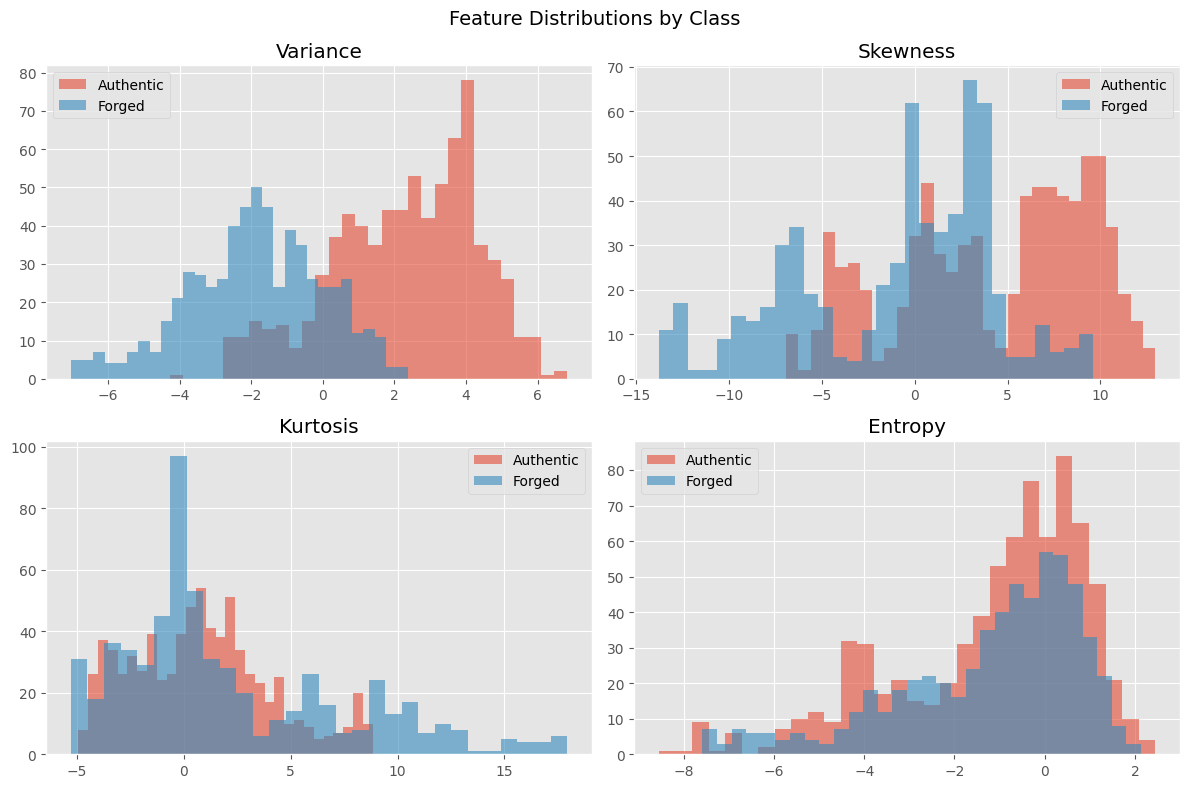

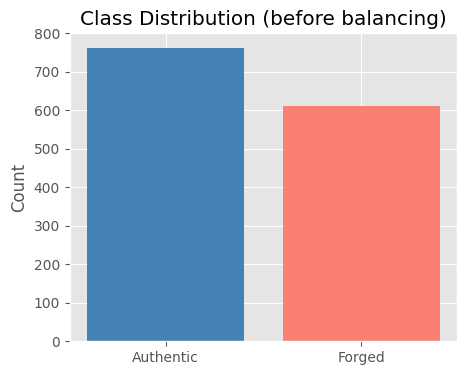

In [13]:
FEATURE_NAMES = ["Variance", "Skewness", "Kurtosis", "Entropy"]
CLASS_LABELS = {0: "Authentic", 1: "Forged"}

# ── 4.1 Feature distributions by class ────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for idx, (ax, name) in enumerate(zip(axes.ravel(), FEATURE_NAMES)):
    for cls in [0, 1]:
        ax.hist(
            X_raw[y_raw == cls, idx],
            bins=30,
            alpha=0.6,
            label=CLASS_LABELS[cls],
        )
    ax.set_title(name)
    ax.legend()
fig.suptitle("Feature Distributions by Class", fontsize=14)
plt.tight_layout()
plt.show()

# ── 4.2 Class balance ─────────────────────────────────────────────────────────
unique, counts = np.unique(y_raw, return_counts=True)
plt.figure(figsize=(5, 4))
plt.bar([CLASS_LABELS[c] for c in unique], counts, color=["steelblue", "salmon"])
plt.title("Class Distribution (before balancing)")
plt.ylabel("Count")
plt.show()

## 5. Preprocessing & Feature Engineering

Operations performed:

1. Stratified train/test split (70 / 30) to preserve class proportions.
2. Random undersampling on both splits to balance the classes (avoids bias toward the majority class).
3. No feature scaling is applied here — the Perceptron update rule is not gradient-magnitude-sensitive in the same way as gradient descent, and the features are already on comparable scales.

In [14]:
# ── 5.1 Train / test split ────────────────────────────────────────────────────
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw,
    y_raw,
    test_size=0.3,
    random_state=SEED,
    stratify=y_raw,
)


# ── 5.2 Undersampling utility ─────────────────────────────────────────────────
def undersample(
    X: np.ndarray,
    y: np.ndarray,
    random_state: int = SEED,
) -> tuple[np.ndarray, np.ndarray]:
    """Balance classes via random undersampling of the majority class."""
    rng = np.random.RandomState(random_state)
    classes, counts = np.unique(y, return_counts=True)
    min_count = counts.min()

    balanced_indices: list[np.ndarray] = []
    for cls in classes:
        cls_idx = np.where(y == cls)[0]
        sampled = rng.choice(cls_idx, size=min_count, replace=False)
        balanced_indices.append(sampled)

    indices = np.concatenate(balanced_indices)
    rng.shuffle(indices)
    return X[indices], y[indices]


X_train, y_train = undersample(X_train_raw, y_train_raw)
X_test, y_test = undersample(X_test_raw, y_test_raw)

# ── 5.3 Verify shapes & balance ───────────────────────────────────────────────
print(f"Training set shape: {X_train.shape}")
print(f"Test set shape:     {X_test.shape}")
print(f"\nTraining class distribution: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Test class distribution:     {dict(zip(*np.unique(y_test, return_counts=True)))}")

print(f"\nFirst 5 training samples:\n{X_train[:5]}")
print(f"\nFirst 5 training labels: {y_train[:5]}")

Training set shape: (854, 4)
Test set shape:     (366, 4)

Training class distribution: {np.int64(0): np.int64(427), np.int64(1): np.int64(427)}
Test class distribution:     {np.int64(0): np.int64(183), np.int64(1): np.int64(183)}

First 5 training samples:
[[-3.57130e+00 -1.24922e+01  1.48881e+01 -4.70270e-01]
 [ 4.88510e+00  1.59950e+00 -2.90810e-04  1.64010e+00]
 [ 1.76200e+00  4.36820e+00  2.13840e+00  7.54290e-01]
 [-2.18880e-01 -2.20380e+00 -9.54000e-02  5.64210e-01]
 [ 2.09300e+00  8.30610e+00  2.28440e-02 -3.27240e+00]]

First 5 training labels: [1 0 0 1 0]


## 6. Model Training

**Selected Model:**  
Simplified (single-layer) Perceptron — implemented from scratch to satisfy the assignment requirements.

**Key Hyperparameters:**

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| Initial weights | `[0.1, -0.2, 0.2, -0.3]` | Small random-like values to break symmetry |
| Initial bias | `0.3` | Small positive value |
| Learning rate | `0.2` | Moderate — fast enough to converge within 100 epochs |
| Epochs | `100` | Sufficient for convergence on this dataset |

**Training Strategy:**  
Online (stochastic) updates — weights are adjusted after every single sample.

In [15]:
# ── 6.1 Perceptron building blocks ────────────────────────────────────────────

def weighted_sum(weights: list[float], inputs: list[float], bias: float) -> float:
    """Compute the weighted sum: z = w · x + b."""
    return bias + sum(w_j * x_j for w_j, x_j in zip(weights, inputs))


def step_activation(z: float) -> int:
    """Heaviside step function: returns 1 if z >= 0, else 0."""
    return int(z >= 0)


def update_parameter(
    param: float,
    learning_rate: float,
    error: float,
    input_value: float = 1.0,
) -> float:
    """Perceptron parameter update: p_new = p + lr * error * x."""
    return param + learning_rate * error * input_value

In [16]:
# ── 6.2 Hyperparameters ───────────────────────────────────────────────────────
INITIAL_WEIGHTS = [0.1, -0.2, 0.2, -0.3]
INITIAL_BIAS = 0.3
LEARNING_RATE = 0.2
EPOCHS = 100

# ── 6.3 Training loop ─────────────────────────────────────────────────────────
weights = INITIAL_WEIGHTS.copy()
bias = INITIAL_BIAS
epoch_errors: list[float] = []

for epoch in range(1, EPOCHS + 1):
    misclassifications = 0

    for x_sample, y_true in zip(X_train, y_train):
        # Forward pass
        z = weighted_sum(weights, x_sample.tolist(), bias)
        y_pred = step_activation(z)

        # Error
        error = y_true - y_pred

        if error != 0:
            # Update weights
            weights = [
                update_parameter(w_j, LEARNING_RATE, error, x_j)
                for w_j, x_j in zip(weights, x_sample)
            ]
            # Update bias
            bias = update_parameter(bias, LEARNING_RATE, error)
            misclassifications += 1

    mean_error = misclassifications / len(y_train)
    epoch_errors.append(mean_error)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:>3d}/{EPOCHS}  —  Mean error: {mean_error:.4f}")

print(f"\nTraining complete.")
print(f"Final weights: {[round(w, 4) for w in weights]}")
print(f"Final bias:    {bias:.4f}")

Epoch   1/100  —  Mean error: 0.0703
Epoch  10/100  —  Mean error: 0.0129
Epoch  20/100  —  Mean error: 0.0211
Epoch  30/100  —  Mean error: 0.0117
Epoch  40/100  —  Mean error: 0.0129
Epoch  50/100  —  Mean error: 0.0129
Epoch  60/100  —  Mean error: 0.0164
Epoch  70/100  —  Mean error: 0.0187
Epoch  80/100  —  Mean error: 0.0176
Epoch  90/100  —  Mean error: 0.0105
Epoch 100/100  —  Mean error: 0.0129

Training complete.
Final weights: [np.float64(-21.7147), np.float64(-13.4737), np.float64(-16.0299), np.float64(-2.6628)]
Final bias:    20.9000


## 7. Model Evaluation

Evaluate the trained Perceptron on the unseen, balanced test set.

Includes:
- Accuracy metric
- Training convergence curve
- Simple confusion breakdown

In [17]:
# ── 7.1 Prediction helper ─────────────────────────────────────────────────────

def predict(x: np.ndarray, w: list[float], b: float) -> int:
    """Predict class label for a single sample."""
    z = weighted_sum(w, x.tolist(), b)
    return step_activation(z)


# ── 7.2 Test-set predictions ──────────────────────────────────────────────────
y_pred = np.array([predict(x, weights, bias) for x in X_test])

accuracy = np.mean(y_pred == y_test)
print("=" * 45)
print("       TEST SET RESULTS")
print("=" * 45)
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Correct:  {int(np.sum(y_pred == y_test))} / {len(y_test)}")

# ── 7.3 Simple confusion breakdown ────────────────────────────────────────────
tp = int(np.sum((y_pred == 1) & (y_test == 1)))
tn = int(np.sum((y_pred == 0) & (y_test == 0)))
fp = int(np.sum((y_pred == 1) & (y_test == 0)))
fn = int(np.sum((y_pred == 0) & (y_test == 1)))

print(f"\nConfusion Matrix:")
print(f"                Predicted 0   Predicted 1")
print(f"  Actual 0      {tn:>10d}   {fp:>10d}")
print(f"  Actual 1      {fn:>10d}   {tp:>10d}")

       TEST SET RESULTS
Accuracy: 99.18%
Correct:  363 / 366

Confusion Matrix:
                Predicted 0   Predicted 1
  Actual 0             180            3
  Actual 1               0          183


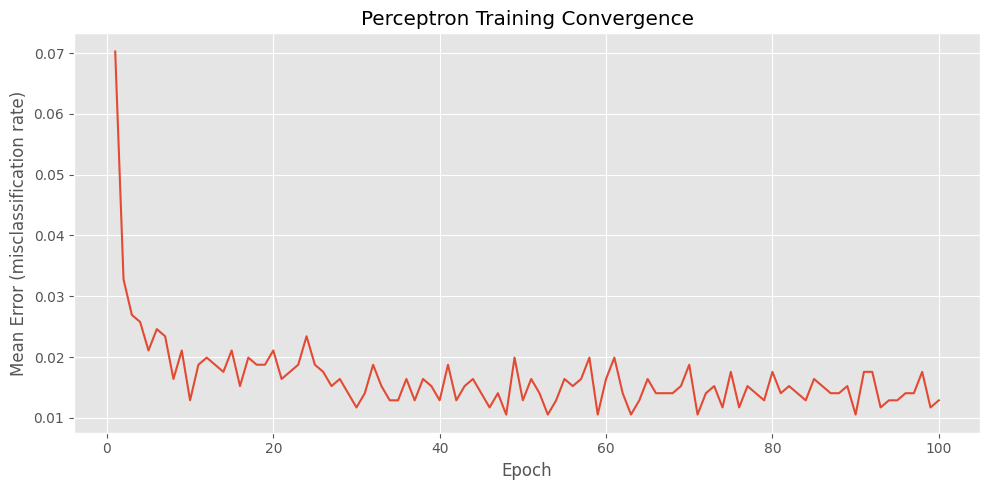

In [18]:
# ── 7.4 Training convergence plot ─────────────────────────────────────────────
plt.figure(figsize=(10, 5))
plt.plot(range(1, EPOCHS + 1), epoch_errors, linewidth=1.5)
plt.xlabel("Epoch")
plt.ylabel("Mean Error (misclassification rate)")
plt.title("Perceptron Training Convergence")
plt.tight_layout()
plt.show()

## 8. Conclusions & Next Steps

**Key Findings:**  
The Perceptron reached 99.18% test accuracy (363/366), with zero false negatives and only 3 false positives. Training accuracy was 98.71%, so there is no overfitting.

| | Pred. 0 | Pred. 1 |
|---|---|---|
| Actual 0 | 180 | 3 |
| Actual 1 | 0 | 183 |

Every forged banknote was caught. The 3 errors were authentic notes flagged as forged — acceptable in fraud detection where missing a counterfeit is worse.

**Model Performance:**  
Training error went from 7% at epoch 1 down to ~1.3% by epoch 10, then oscillated around 1–1.8% without ever hitting zero. This is expected: the data is not perfectly linearly separable, so the online update rule keeps adjusting around a few borderline samples. The learned weights show that Variance (|w| = 21.71) drives the decision the most, followed by Kurtosis (16.03) and Skewness (13.47). Entropy barely contributes (|w| = 2.66) and could probably be dropped.

**Limitations:**  
The Perceptron only learns linear boundaries, undersampling discarded 152 samples, and the step function gives no confidence score.

**Future Work:**  

- Try an MLP with backpropagation to see if the remaining ~1% error can be reduced.
- Use k-fold cross-validation for more reliable estimates.
- Test dropping Entropy to check if a 3-feature model performs just as well.
- Compare against scikit-learn's `Perceptron` and `MLPClassifier`.